# 2024 ranking walkthrough

In-process replica of `scripts/record_vs_diff.py` + `scripts/record_vs_diff_charts.py`. No `scripts/` imports. No writes to `data/` or `figures/`.

Contracts: [README](../README.md) · [feature engineering](../docs/feature-engineering.md) · [analysis](../docs/record-vs-point-diff-analysis.md) · [pipeline](../docs/analysis-pipeline.md).

| Requirement | Spec |
| --- | --- |
| Input | `data/nflverse_2024_reg_games.csv` |
| Runtime | `pandas`, `matplotlib`, `seaborn` |
| Kernel | **Python (510-m1)** |


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

# Notebook may be opened from the repo root or from notebooks/.
root = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
# One row per completed 2024 regular-season game (272 games).
GAMES_PATH = root / "data" / "nflverse_2024_reg_games.csv"
# Flag a mismatch when record place and scoring place differ by 6+ spots
# (about a fifth of the 32-team league).
MISMATCH_RANK_GAP = 6

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 40)

print(f"games CSV: {GAMES_PATH.relative_to(root)}")
print(f"exists: {GAMES_PATH.is_file()}")


games CSV: data/nflverse_2024_reg_games.csv
exists: True


## 1. Extract — game grain

Load `data/nflverse_2024_reg_games.csv` (272 REG games). Unpivot mapping: [feature engineering](../docs/feature-engineering.md).


In [2]:
# Download/filter already happened in scripts/pull_schedules.py; this cell only reads.
games = pd.read_csv(GAMES_PATH)

print(f"rows (games): {len(games)}")
print(f"weeks: {int(games['week'].min())}–{int(games['week'].max())}")
print(f"unique home+away teams: {pd.concat([games['home_team'], games['away_team']]).nunique()}")

# First game: Baltimore at Kansas City, week 1.
# Scores are still split across home_* and away_* — not yet one row per team.
display(games.loc[[0], ["week", "home_team", "home_score", "away_team", "away_score"]])


rows (games): 272
weeks: 1–18
unique home+away teams: 32


,week,home_team,home_score,away_team,away_score
0,1,KC,27.0,BAL,20.0


## 2. Unpivot — team-game grain

`games_to_team_rows`: 1 game → 2 team-games. Expected n = 544. Not persisted. Derivations: [feature engineering](../docs/feature-engineering.md).


In [3]:
def games_to_team_rows(games: pd.DataFrame) -> pd.DataFrame:
    """Split each game into two rows: one for the home team, one for the away team."""
    # Copy the home side: this team scored home_score and allowed away_score.
    home_rows = pd.DataFrame(
        {
            "week": games["week"],
            "team": games["home_team"],
            "points_for": games["home_score"],
            "points_against": games["away_score"],
        }
    )
    # Copy the away side: scores are swapped.
    away_rows = pd.DataFrame(
        {
            "week": games["week"],
            "team": games["away_team"],
            "points_for": games["away_score"],
            "points_against": games["home_score"],
        }
    )
    # Stack home and away into one table (544 team-game rows from 272 games).
    team_games = pd.concat([home_rows, away_rows], ignore_index=True)
    # Win if you scored more; 2024 regular season in this extract has no ties.
    team_games["win"] = (team_games["points_for"] > team_games["points_against"]).astype(int)
    team_games["loss"] = (team_games["points_for"] < team_games["points_against"]).astype(int)
    # Scored minus allowed for this team in this game (not in the nflverse file).
    team_games["point_diff"] = team_games["points_for"] - team_games["points_against"]
    return team_games


team_games = games_to_team_rows(games)
print(f"rows (team-games): {len(team_games)}")
print(f"columns: {list(team_games.columns)}")

# Same week-1 game, now one row for KC and one for BAL.
week1_opener = team_games.loc[
    (team_games["week"] == 1) & (team_games["team"].isin(["KC", "BAL"]))
]
display(week1_opener.reset_index(drop=True))


rows (team-games): 544
columns: ['week', 'team', 'points_for', 'points_against', 'win', 'loss', 'point_diff']


,week,team,points_for,points_against,win,loss,point_diff
0,1,KC,27.0,20.0,1,0,7.0
1,1,BAL,20.0,27.0,0,1,-7.0


## 3. Aggregate — team-season grain

`summarize_season`: `groupby("team")`. Expected `games = 17` for all 32 clubs. Dictionary: [feature engineering](../docs/feature-engineering.md).


In [4]:
def summarize_season(team_games: pd.DataFrame) -> pd.DataFrame:
    """One row per team: games, wins, losses, season point_diff, win_pct."""
    # size = games played. sum of win/loss = the W–L record.
    season_totals = (
        team_games.groupby("team", as_index=False)
        .agg(
            games=("win", "size"),
            wins=("win", "sum"),
            losses=("loss", "sum"),
            point_diff=("point_diff", "sum"),
        )
    )
    # Win percentage = wins / games played (17 for every team here).
    season_totals["win_pct"] = season_totals["wins"] / season_totals["games"]
    return season_totals


season_totals = summarize_season(team_games)
print(f"rows (teams): {len(season_totals)}")
print(f"games per team: {sorted(season_totals['games'].unique().tolist())}")

# Detroit and Kansas City both went 15–2. Only the scoring column splits them.
display(
    season_totals.loc[season_totals["team"].isin(["DET", "KC"])]
    .sort_values("team")
    .reset_index(drop=True)
)


rows (teams): 32
games per team: [17]


,team,games,wins,losses,point_diff,win_pct
0,DET,17,15,2,222.0,0.882353
1,KC,17,15,2,59.0,0.882353


## 4. Ranks and mismatch

Apply `rank_min` on `win_pct` and `point_diff`; `rank_gap`, `mismatch`, `record_ahead_by` per the season dictionary. Do not persist.


In [5]:
def build_season_table(games: pd.DataFrame) -> pd.DataFrame:
    """One row per team: 2024 record vs scoring, plus a mismatch flag."""
    team_games = games_to_team_rows(games)
    teams = summarize_season(team_games)
    # 1 = best. KC and DET both 15–2 → both 1st; the next teams are 3rd.
    teams["rank_win_pct"] = teams["win_pct"].rank(ascending=False, method="min").astype(int)
    teams["rank_point_diff"] = (
        teams["point_diff"].rank(ascending=False, method="min").astype(int)
    )
    teams["rank_gap"] = (teams["rank_win_pct"] - teams["rank_point_diff"]).abs()
    teams["mismatch"] = teams["rank_gap"] >= MISMATCH_RANK_GAP
    # Positive: how far record place sits ahead of scoring place.
    teams["record_ahead_by"] = teams["rank_point_diff"] - teams["rank_win_pct"]
    return teams.sort_values(["rank_win_pct", "team"]).reset_index(drop=True)


teams = build_season_table(games)
print(f"rows: {len(teams)}")
print(f"columns: {list(teams.columns)}")
print(f"mismatch teams: {int(teams['mismatch'].sum())}")
display(teams)


rows: 32
columns: ['team', 'games', 'wins', 'losses', 'point_diff', 'win_pct', 'rank_win_pct', 'rank_point_diff', 'rank_gap', 'mismatch', 'record_ahead_by']
mismatch teams: 5


,team,games,wins,losses,point_diff,win_pct,rank_win_pct,rank_point_diff,rank_gap,mismatch,record_ahead_by
0,DET,17,15,2,222.0,0.882353,1,1,0,False,0
1,KC,17,15,2,59.0,0.882353,1,11,10,True,10
2,MIN,17,14,3,100.0,0.823529,3,9,6,True,6
3,PHI,17,14,3,160.0,0.823529,3,2,1,False,-1
4,BUF,17,13,4,157.0,0.764706,5,3,2,False,-2
5,BAL,17,12,5,157.0,0.705882,6,3,3,False,-3
6,WAS,17,12,5,94.0,0.705882,6,10,4,False,4
7,GB,17,11,6,122.0,0.647059,8,5,3,False,-3
8,LAC,17,11,6,101.0,0.647059,8,8,0,False,0
9,DEN,17,10,7,114.0,0.588235,10,7,3,False,-3


## 5. Verification — DET vs KC

Expected from [analysis](../docs/record-vs-point-diff-analysis.md): DET `rank_gap = 0`; KC `mismatch = true`, `record_ahead_by = 10`.


In [6]:
# Ranking columns only, for the two teams that shared 15–2.
pair = teams.loc[
    teams["team"].isin(["DET", "KC"]),
    [
        "team",
        "wins",
        "losses",
        "point_diff",
        "rank_win_pct",
        "rank_point_diff",
        "rank_gap",
        "mismatch",
        "record_ahead_by",
    ],
]
display(pair.reset_index(drop=True))


,team,wins,losses,point_diff,rank_win_pct,rank_point_diff,rank_gap,mismatch,record_ahead_by
0,DET,15,2,222.0,1,1,0,False,0
1,KC,15,2,59.0,1,11,10,True,10


## 6. Mismatch subset

Filter `mismatch == true`. Canonical five-row set: [analysis](../docs/record-vs-point-diff-analysis.md).


In [7]:
# Same 32-row table, filtered to mismatch == True, largest gap first.
mismatch_teams = teams.loc[teams["mismatch"]].sort_values(
    "record_ahead_by", ascending=False
)
display(mismatch_teams.reset_index(drop=True))


,team,games,wins,losses,point_diff,win_pct,rank_win_pct,rank_point_diff,rank_gap,mismatch,record_ahead_by
0,KC,17,15,2,59.0,0.882353,1,11,10,True,10
1,CAR,17,5,12,-193.0,0.294118,23,32,9,True,9
2,LA,17,10,7,-19.0,0.588235,10,17,7,True,7
3,MIN,17,14,3,100.0,0.823529,3,9,6,True,6
4,HOU,17,10,7,0.0,0.588235,10,16,6,True,6


## 7. Charts

In-notebook render only. PNG writers: `scripts/record_vs_diff_charts.py`. Encoding: [analysis](../docs/record-vs-point-diff-analysis.md).


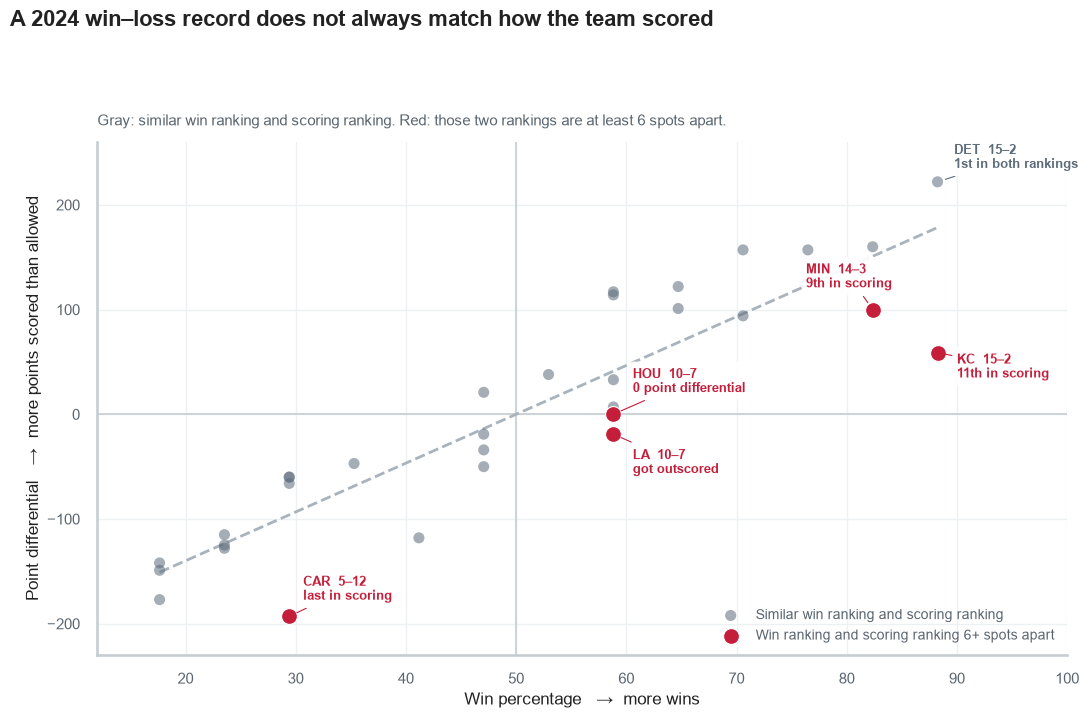

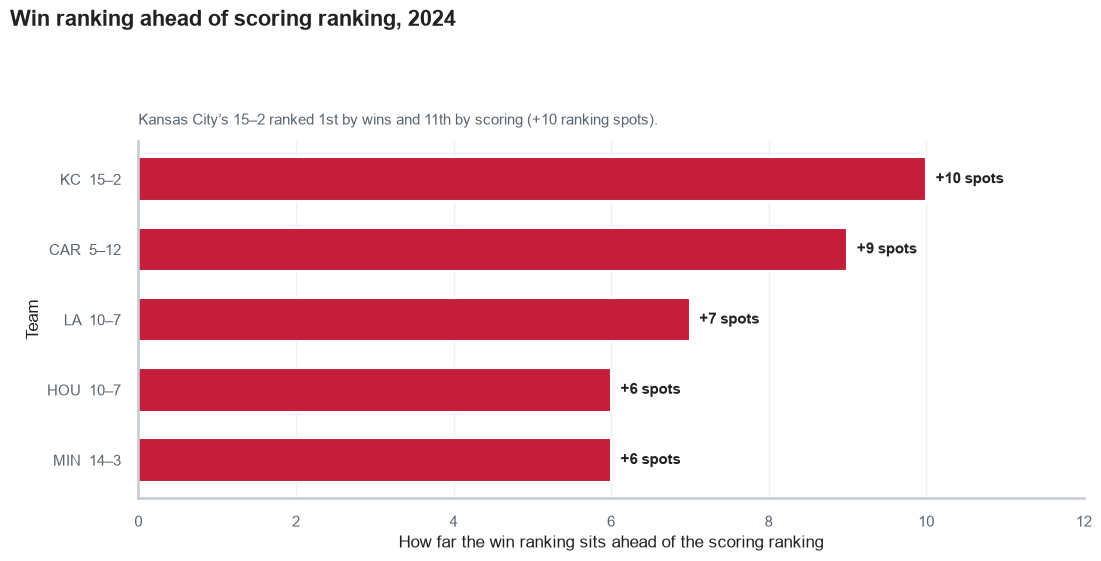

In [8]:
# Labels used only for the pictures (not part of the ranking CSV).
# win_percent is 0–100 so 50 sits at .500 on the scatter.
teams["win_percent"] = teams["win_pct"] * 100
teams["record"] = teams["wins"].astype(int).astype(str) + "–" + teams["losses"].astype(int).astype(str)
teams["label"] = teams["team"] + "  " + teams["record"]

# Red = mismatch; gray = record and scoring agree.
MISMATCH_COLOR = "#c41e3a"
MATCH_COLOR = "#5c6b7a"
TREND_COLOR = "#a8b3bd"
TITLE_COLOR = "#222222"
MUTED_TEXT = "#5a6570"
# Pixel offsets keep three-line labels off the dots and each other.
LABEL_OFFSET = {
    "KC": (16, -26),
    "DET": (12, 12),
    "MIN": (-78, 20),
    "HOU": (16, 20),
    "LA": (16, -36),
    "CAR": (12, 16),
}


def ordinal(n):
    """English ordinal for a ranking place (1 → 1st, 11 → 11th)."""
    n = int(n)
    if 10 <= (n % 100) <= 20:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"


def scatter_callout(row):
    """Record, then both places among 32 (record place and scoring place)."""
    record_line = f"{row['team']}  {row['record']}"
    win_line = f"{ordinal(row['rank_win_pct'])} of 32 by record"
    scoring_line = f"{ordinal(row['rank_point_diff'])} of 32 by scoring"
    return f"{record_line}\n{win_line}\n{scoring_line}"


def style_slide_axes(ax: plt.Axes) -> None:
    """Clean spines and ticks for a slide, not a spreadsheet."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#c5ccd3")
    ax.spines["bottom"].set_color("#c5ccd3")
    ax.tick_params(colors=MUTED_TEXT, labelsize=11)
    ax.grid(axis="both", color="#eef1f4", linewidth=1)
    ax.set_axisbelow(True)


sns.set_theme(style="white", context="talk")

# --- Scatter: win% vs point differential ---
fig, ax = plt.subplots(figsize=(11.2, 7.4))
fig.patch.set_facecolor("white")
matching_teams = teams.loc[~teams["mismatch"]]
mismatch_dots = teams.loc[teams["mismatch"]]
# Dashed line = usual pairing of better record with better margin.
sns.regplot(
    data=teams,
    x="win_percent",
    y="point_diff",
    scatter=False,
    ax=ax,
    color=TREND_COLOR,
    line_kws={"linewidth": 2, "linestyle": "--"},
    ci=None,
)
ax.scatter(
    matching_teams["win_percent"],
    matching_teams["point_diff"],
    c=MATCH_COLOR,
    s=64,
    alpha=0.55,
    label="Record and scoring agree",
    zorder=2,
    edgecolors="none",
)
ax.scatter(
    mismatch_dots["win_percent"],
    mismatch_dots["point_diff"],
    c=MISMATCH_COLOR,
    s=130,
    label="Mismatch: 6+ places apart",
    zorder=3,
    edgecolors="white",
    linewidths=0.8,
)
for _, row in teams.loc[teams["team"].isin(LABEL_OFFSET)].iterrows():
    color = MISMATCH_COLOR if row["mismatch"] else MATCH_COLOR
    ax.annotate(
        scatter_callout(row),
        (row["win_percent"], row["point_diff"]),
        textcoords="offset points",
        xytext=LABEL_OFFSET[row["team"]],
        fontsize=9.5,
        color=color,
        fontweight="bold",
        linespacing=1.25,
        bbox={
            "boxstyle": "round,pad=0.28",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.92,
        },
        arrowprops={"arrowstyle": "-", "color": color, "lw": 0.8, "shrinkA": 1, "shrinkB": 6},
    )
ax.axhline(0, color="#c5ccd3", linewidth=1.2, zorder=1)
ax.axvline(50, color="#c5ccd3", linewidth=1.2, zorder=1)
ax.set_xlabel("Win percentage   →  more wins", fontsize=12, color=TITLE_COLOR)
ax.set_ylabel("Point differential   →  more points scored than allowed", fontsize=12, color=TITLE_COLOR)
fig.suptitle(
    "A 2024 win–loss record does not always match how the team scored",
    fontsize=16,
    fontweight="bold",
    color=TITLE_COLOR,
    x=0.01,
    ha="left",
    y=0.98,
)
ax.set_title(
    "Gray: record and scoring agree. Red: mismatch (places differ by 6 or more). "
    "Neither ranking, in a vacuum, is team strength.",
    fontsize=11,
    color=MUTED_TEXT,
    loc="left",
    pad=12,
)
ax.legend(frameon=False, loc="lower right", fontsize=10, labelcolor=MUTED_TEXT)
ax.set_xlim(12, 100)
ax.set_ylim(-230, 260)
style_slide_axes(ax)
fig.tight_layout(rect=(0, 0, 1, 0.94))
display(fig)
plt.close(fig)

# --- Bar: how far the record sat ahead of the scores ---
bar_teams = teams.loc[teams["mismatch"]].sort_values("record_ahead_by", ascending=True).copy()
bar_teams["bar_label"] = (
    bar_teams["team"] + "  " + bar_teams["record"]
    + " · " + bar_teams["rank_win_pct"].map(ordinal) + " of 32 by record · "
    + bar_teams["rank_point_diff"].map(ordinal) + " of 32 by scoring"
)
fig, ax = plt.subplots(figsize=(11.2, 5.8))
fig.patch.set_facecolor("white")
ax.barh(
    bar_teams["bar_label"],
    bar_teams["record_ahead_by"],
    color=MISMATCH_COLOR,
    height=0.62,
    zorder=2,
)
for y, (_, row) in enumerate(bar_teams.iterrows()):
    ax.text(
        row["record_ahead_by"] + 0.12,
        y,
        f"+{int(row['record_ahead_by'])} spots",
        va="center",
        fontsize=11,
        color=TITLE_COLOR,
        fontweight="bold",
    )
ax.set_xlabel(
    "How far record place sat ahead of scoring place",
    fontsize=12,
    color=TITLE_COLOR,
)
ax.set_ylabel("Team", fontsize=12, color=TITLE_COLOR)
fig.suptitle(
    "Record looked better than the scores, 2024",
    fontsize=16,
    fontweight="bold",
    color=TITLE_COLOR,
    x=0.01,
    ha="left",
    y=0.98,
)
ax.set_title(
    "Kansas City’s 15–2 ranked 1st by wins and 11th by scoring (+10 ranking spots). "
    "Neither ranking, on its own, is enough.",
    fontsize=11,
    color=MUTED_TEXT,
    loc="left",
    pad=12,
)
ax.set_xlim(0, bar_teams["record_ahead_by"].max() + 2)
style_slide_axes(ax)
ax.grid(axis="x", color="#eef1f4", linewidth=1)
ax.grid(axis="y", visible=False)
fig.tight_layout(rect=(0, 0, 1, 0.93))
display(fig)
plt.close(fig)
